In [28]:
import sys, pathlib
import torch
repo_root = pathlib.Path.cwd().parent if (pathlib.Path.cwd().name == "rnencodec_notebooks") else pathlib.Path.cwd()
sys.path.insert(0, str(repo_root))
from inference.rt import run_inference, play_audio

In [29]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

def analyze_representation(audio, norm_sequence, title, sr=24000):
    F_MIN, F_MAX = 234.0, 448.0
    
    # 1. Track Actual Pitch (pYIN)
    f0, _, _ = librosa.pyin(audio, fmin=F_MIN-50, fmax=F_MAX+50, sr=sr)
    times_f0 = librosa.times_like(f0, sr=sr)
    
    # 2. Extract normalized 't' (0 to 1) based on shape
    if norm_sequence.shape[1] == 1:
        # Simple Log-Normalised value
        t = norm_sequence[:, 0]
    elif norm_sequence.shape[1] in [2, 8]:
        # For Sine-Cosine (2) or Fourier (8), we extract 't' from the first pair
        # angles = arctan2(sin, cos)
        angles = np.arctan2(norm_sequence[:, 0], norm_sequence[:, 1])
        # Map radians back to [0, 1] range
        # Use % (2*pi) to handle wrapping, then divide by 2*pi
        t = (angles % (2 * np.pi)) / (2 * np.pi)
    else:
        raise ValueError(f"Unsupported shape: {norm_sequence.shape}")

    # 3. Map 't' back to Hz using the Log-Inverse formula
    # Inverse of: t = (log(freq) - log(fmin)) / (log(fmax) - log(fmin))
    target_hz = np.exp(t * (np.log(F_MAX) - np.log(F_MIN)) + np.log(F_MIN))
    
    times_target = np.linspace(0, len(audio)/sr, len(target_hz))

    # --- Plotting ---
    plt.figure(figsize=(12, 5))
    D = librosa.amplitude_to_db(np.abs(librosa.stft(audio)), ref=np.max)
    librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz', cmap='magma')
    
    plt.plot(times_target, target_hz, color='cyan', linestyle='--', label='Target Hz (Input)', linewidth=2)
    plt.scatter(times_f0, f0, color='lime', s=8, label='Detected Hz (pYIN)', alpha=0.5)
    
    plt.ylim(F_MIN - 40, F_MAX + 40)
    plt.title(f"Fidelity Analysis: {title}")
    plt.legend()
    plt.show()

# 1. Glissando/slide from one point to another

The idea here will be to look at the different representations and see which can actually do a smoother glissando from one point to another.

### 1.1 Frequency representation

Loading model from: output_26.03.19.18.44
Rendering Linear Frequency Slide...
Loaded conditioning config with 1 features:
  - pitch: 230-450 Hz

Loading EnCodec model...


Loading weights:   0%|          | 0/252 [00:00<?, ?it/s]

Using last checkpoint: checkpoint_75.pt
Loading RNN model from checkpoint_75.pt...
Initializing the RNNGeneratorSoft on device = cpu
Latents embedded in 64 of the GRU input size of 128
Conditioning parameters embedded in 64 of the GRU input size of 128
Model loaded successfully!
  - Hidden size: 128
  - Num layers: 3
  - Conditioning size: 1
  - Cascade mode: hard
  - Hard sampling mode: sample
  - Temperature: 0.8
  - Top-k: 8
  - Device: cpu
Generating audio in chunks of 8 frames...


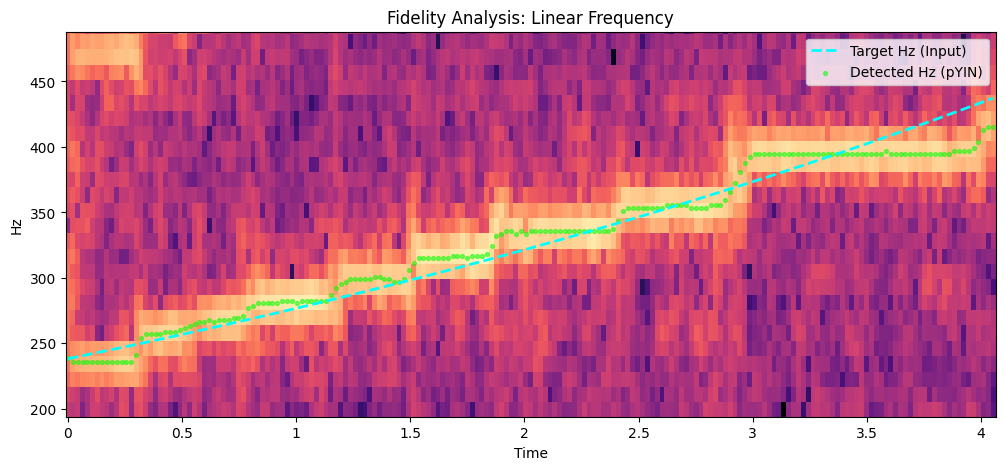

In [30]:
# --- CONFIGURATION ---
MODEL_DIR = "output_26.03.19.18.44"  # Update this to your model path
CHECKPOINT = "last_checkpoint.pt"            # e.g., 'checkpoint_75.pt' or None for latest

print(f"Loading model from: {MODEL_DIR}")

num_frames = 304 # (4s * 75fps, rounded to multiple of 8)
# Create a ramp from 240Hz to 440Hz
hz_ramp = torch.linspace(240, 440, num_frames)
freq_seq = ((hz_ramp - 234) / (448 - 234)).view(-1, 1)

print("Rendering Linear Frequency Slide...")
audio_freq = run_inference(model_dir=MODEL_DIR, mode="offline", conditioning_sequence=freq_seq)
play_audio(audio_freq)
analyze_representation(audio_freq, freq_seq.numpy(), "Linear Frequency")

### 1.2 Class representation

Loading model from: output_26.03.19.23.20
Loaded conditioning config with 11 features:
  - pitch_class_A#3: binary
  - pitch_class_A4: binary
  - pitch_class_C#4: binary
  - pitch_class_C4: binary
  - pitch_class_D#4: binary
  - pitch_class_D4: binary
  - pitch_class_E4: binary
  - pitch_class_F#4: binary
  - pitch_class_F4: binary
  - pitch_class_G#4: binary
  - pitch_class_G4: binary

Loading EnCodec model...


Loading weights:   0%|          | 0/252 [00:00<?, ?it/s]

Using last checkpoint: checkpoint_75.pt
Loading RNN model from checkpoint_75.pt...
Initializing the RNNGeneratorSoft on device = cpu
Latents embedded in 64 of the GRU input size of 128
Conditioning parameters embedded in 64 of the GRU input size of 128
Model loaded successfully!
  - Hidden size: 128
  - Num layers: 3
  - Conditioning size: 11
  - Cascade mode: hard
  - Hard sampling mode: sample
  - Temperature: 0.8
  - Top-k: 8
  - Device: cpu
Generating audio in chunks of 8 frames...


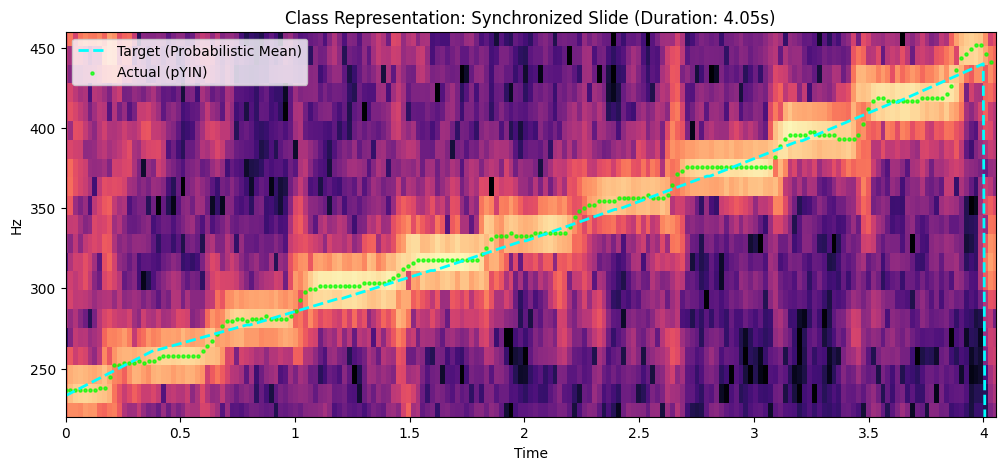

In [40]:
# --- CONFIGURATION ---
MODEL_DIR = "output_26.03.19.23.20"  # Update this to your model path
CHECKPOINT = "last_checkpoint.pt"            # e.g., 'checkpoint_75.pt' or None for latest

print(f"Loading model from: {MODEL_DIR}")

def create_class_slide(duration=6.0, fps=75):
    # The indices in the order of your provided list that make musical sense
    # A#3 -> C4 -> C#4 -> D4 -> D#4 -> E4 -> F4 -> F#4 -> G4 -> G#4 -> A4
    musical_path = [0, 3, 2, 5, 4, 6, 8, 7, 10, 9, 1]
    num_notes = len(musical_path)
    
    total_frames = int(duration * fps)
    total_frames += (8 - total_frames % 8) # Hopsize alignment
    
    slide_values = torch.zeros(total_frames, 11)
    
    # Frames allocated for each transition
    frames_per_transition = total_frames // (num_notes - 1)
    
    for i in range(num_notes - 1):
        start_idx = musical_path[i]
        end_idx = musical_path[i+1]
        
        t_start = i * frames_per_transition
        t_end = (i + 1) * frames_per_transition
        
        # Create the cross-fade ramp
        alpha = torch.linspace(0, 1, t_end - t_start)
        
        # Decrease probability of current note, increase next one
        slide_values[t_start:t_end, start_idx] = 1.0 - alpha
        slide_values[t_start:t_end, end_idx] = alpha
        
    return slide_values

def analyze_class_representation_fixed(audio, norm_sequence, sr=24000, fps=75):
    # 1. TRUNCATE AUDIO TO MATCH CONDITIONING
    # The number of audio samples should exactly match the number of frames / fps
    expected_duration = len(norm_sequence) / fps
    num_samples_to_keep = int(expected_duration * sr)
    
    # Clip the audio so it doesn't "hang over"
    audio = audio[:num_samples_to_keep]
    
    # Standard frequencies for your classes
    class_hz = np.array([
        233.08, 440.00, 277.18, 261.63, 311.13, 293.66, 
        329.63, 369.99, 349.23, 415.30, 392.00
    ])
    
    # 2. Track Actual Pitch on the CLIPPED audio
    f0, voiced_flag, voiced_probs = librosa.pyin(audio, fmin=200, fmax=500, sr=sr)
    times_f0 = librosa.times_like(f0, sr=sr)
    
    # 3. Calculate Target Hz
    target_hz = np.dot(norm_sequence, class_hz)
    # Time axis for target must span exactly the clipped audio duration
    times_target = np.linspace(0, len(audio)/sr, len(target_hz))
    
    # Plotting
    plt.figure(figsize=(12, 5))
    
    # STFT on clipped audio
    D = librosa.amplitude_to_db(np.abs(librosa.stft(audio)), ref=np.max)
    
    # Use 'x_coords' to ensure librosa doesn't guess the time axis incorrectly
    librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz', cmap='magma', 
                             vmax=0, vmin=-60) # Contrast boost
    
    plt.plot(times_target, target_hz, color='cyan', linestyle='--', 
             label='Target (Probabilistic Mean)', linewidth=2)
    
    plt.scatter(times_f0, f0, color='lime', s=5, label='Actual (pYIN)', alpha=0.7)
    
    plt.title(f"Class Representation: Synchronized Slide (Duration: {expected_duration:.2f}s)")
    plt.ylim(220, 460)
    plt.xlim(0, expected_duration) # Hard limit the x-axis
    plt.legend()
    plt.show()

# --- RUNNING ---
class_seq = create_class_slide(duration=4.0)
audio_class = run_inference(MODEL_DIR, mode="offline", conditioning_sequence=class_seq)
play_audio(audio_class)

# Analyze with the new clipping logic
analyze_class_representation_fixed(audio_class, class_seq.numpy())

### 1.3 Sine-cosine representation

Loading model from: output_26.03.20.01.34
Rendering Sine-Cosine Slide...
Loaded conditioning config with 2 features:
  - pitch_sin: -1.0-1.0 sine
  - pitch_cos: -1.0-1.0 cosine

Loading EnCodec model...


Loading weights:   0%|          | 0/252 [00:00<?, ?it/s]

Using last checkpoint: checkpoint_75.pt
Loading RNN model from checkpoint_75.pt...
Initializing the RNNGeneratorSoft on device = cpu
Latents embedded in 64 of the GRU input size of 128
Conditioning parameters embedded in 64 of the GRU input size of 128
Model loaded successfully!
  - Hidden size: 128
  - Num layers: 3
  - Conditioning size: 2
  - Cascade mode: hard
  - Hard sampling mode: sample
  - Temperature: 0.8
  - Top-k: 8
  - Device: cpu
Generating audio in chunks of 8 frames...


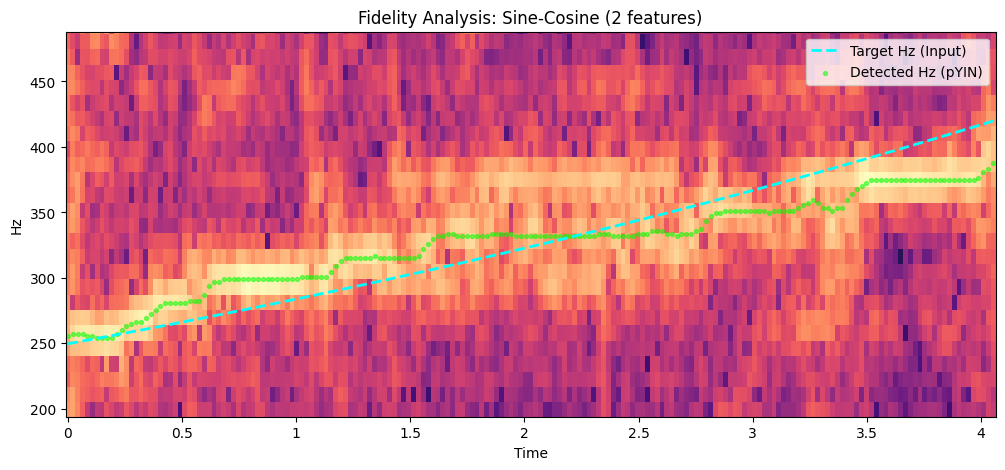

In [32]:
# --- CONFIGURATION ---
import numpy as np

MODEL_DIR = "output_26.03.20.01.34"  # Update this to your model path
CHECKPOINT = "last_checkpoint.pt"            # e.g., 'checkpoint_75.pt' or None for latest

print(f"Loading model from: {MODEL_DIR}")

num_frames = 304 
F_MIN, F_MAX = 234.0, 448.0

# Create log-normalized 't' ramp
t = torch.linspace(0.1, 0.9, num_frames) 
angle = 2 * np.pi * t

sc_seq = torch.stack([torch.sin(angle), torch.cos(angle)], dim=1)

print("Rendering Sine-Cosine Slide...")
audio_sc = run_inference(MODEL_DIR, mode="offline", conditioning_sequence=sc_seq)
play_audio(audio_sc)
analyze_representation(audio_sc, sc_seq.numpy(), "Sine-Cosine (2 features)")

### 1.4 Fourier representation

Loading model from: output_26.03.20.02.35
Rendering Fourier Slide (8 features)...
Loaded conditioning config with 8 features:
  - pitch_sin_1: -1.0-1.0 sine_component_1
  - pitch_cos_1: -1.0-1.0 cosine_component_1
  - pitch_sin_2: -1.0-1.0 sine_component_2
  - pitch_cos_2: -1.0-1.0 cosine_component_2
  - pitch_sin_3: -1.0-1.0 sine_component_3
  - pitch_cos_3: -1.0-1.0 cosine_component_3
  - pitch_sin_4: -1.0-1.0 sine_component_4
  - pitch_cos_4: -1.0-1.0 cosine_component_4

Loading EnCodec model...


Loading weights:   0%|          | 0/252 [00:00<?, ?it/s]

Using last checkpoint: checkpoint_75.pt
Loading RNN model from checkpoint_75.pt...
Initializing the RNNGeneratorSoft on device = cpu
Latents embedded in 64 of the GRU input size of 128
Conditioning parameters embedded in 64 of the GRU input size of 128
Model loaded successfully!
  - Hidden size: 128
  - Num layers: 3
  - Conditioning size: 8
  - Cascade mode: hard
  - Hard sampling mode: sample
  - Temperature: 0.8
  - Top-k: 8
  - Device: cpu
Generating audio in chunks of 8 frames...


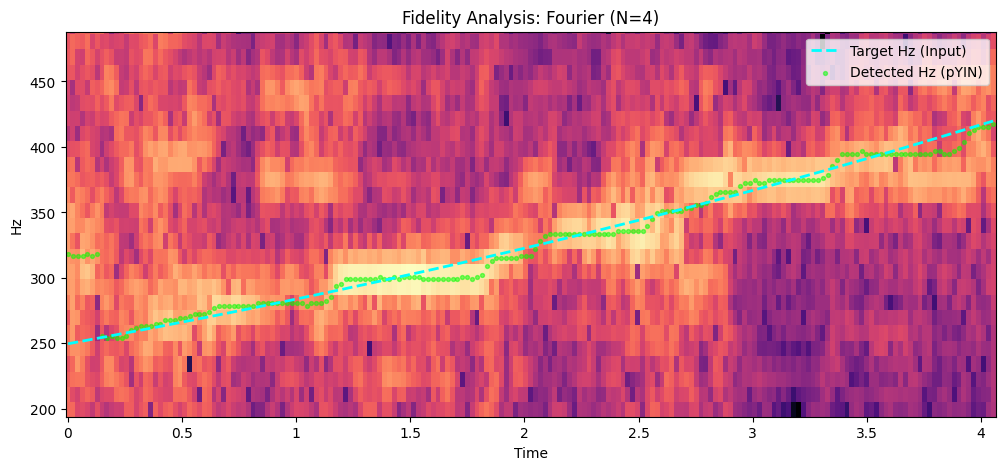

In [33]:
# --- CONFIGURATION ---
MODEL_DIR = "output_26.03.20.02.35"  # Update this to your model path
CHECKPOINT = "last_checkpoint.pt"            # e.g., 'checkpoint_75.pt' or None for latest

print(f"Loading model from: {MODEL_DIR}")

N_FOURIER = 4 # Change this to match your trained model config!
num_features = N_FOURIER * 2
fourier_seq = torch.zeros(num_frames, num_features)

t = torch.linspace(0.1, 0.9, num_frames)

for k in range(1, N_FOURIER + 1):
    fourier_seq[:, 2*(k-1)]   = torch.sin(2 * np.pi * k * t)
    fourier_seq[:, 2*(k-1)+1] = torch.cos(2 * np.pi * k * t)

print(f"Rendering Fourier Slide ({num_features} features)...")
audio_four = run_inference(MODEL_DIR, mode="offline", conditioning_sequence=fourier_seq)
play_audio(audio_four)
analyze_representation(audio_four, fourier_seq.numpy(), f"Fourier (N={N_FOURIER})")

### 1.5 Log-norm representation

Loading model from: output_26.03.20.00.32
Rendering Log-Norm Slide...
Loaded conditioning config with 1 features:
  - pitch_log_norm: 0.0-1.0 log_normalised

Loading EnCodec model...


Loading weights:   0%|          | 0/252 [00:00<?, ?it/s]

Using last checkpoint: checkpoint_75.pt
Loading RNN model from checkpoint_75.pt...
Initializing the RNNGeneratorSoft on device = cpu
Latents embedded in 64 of the GRU input size of 128
Conditioning parameters embedded in 64 of the GRU input size of 128
Model loaded successfully!
  - Hidden size: 128
  - Num layers: 3
  - Conditioning size: 1
  - Cascade mode: hard
  - Hard sampling mode: sample
  - Temperature: 0.8
  - Top-k: 8
  - Device: cpu
Generating audio in chunks of 8 frames...


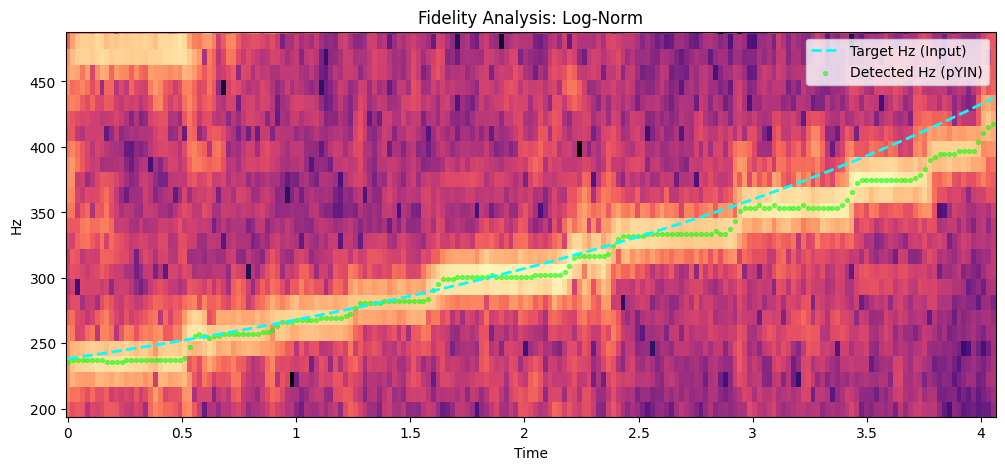

In [34]:
# --- CONFIGURATION ---
MODEL_DIR = "output_26.03.20.00.32"  # Update this to your model path
CHECKPOINT = "last_checkpoint.pt"            # e.g., 'checkpoint_75.pt' or None for latest

print(f"Loading model from: {MODEL_DIR}")

# Create a log-spaced ramp (equal steps in octaves/semitones)
log_hz_ramp = torch.exp(torch.linspace(np.log(240), np.log(440), num_frames))
log_seq = ((log_hz_ramp - 234) / (448 - 234)).view(-1, 1)

print("Rendering Log-Norm Slide...")
audio_log = run_inference(model_dir=MODEL_DIR, mode="offline", conditioning_sequence=log_seq)
play_audio(audio_log)
analyze_representation(audio_log, log_seq.numpy(), "Log-Norm")